# **Tesla End-to-End Machine Learning Pipeline**

Objectives:
- Load and explore Tesla deliveries data
- Perform EDA and data quality checks
- Preprocess data and engineer new features
- Build and evaluate Linear Regression and Random Forest models
- Apply Cross Validation and Hyperparameter Tuning
- Analyze time series behavior using the ADF test
- Forecast Tesla deliveries and assess model performance

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


## Dataset Loading and Initial Inspection

This step loads the dataset and examines its structure.

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
print(df.info())

print("\nDescribe:")
print(df.describe())

Shape: (2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Ch

## Missing Values and Duplicate Check

Checking data quality before analysis

In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows:
0


## Exploratory Data Analysis (EDA)

Visualizing patterns and relationships in the dataset.

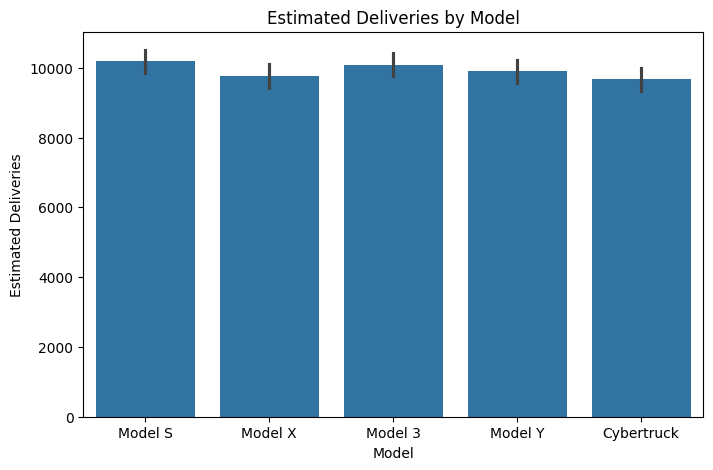

In [5]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model',
            y='Estimated_Deliveries',
            data=df)

plt.title("Estimated Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Estimated Deliveries")
plt.show()

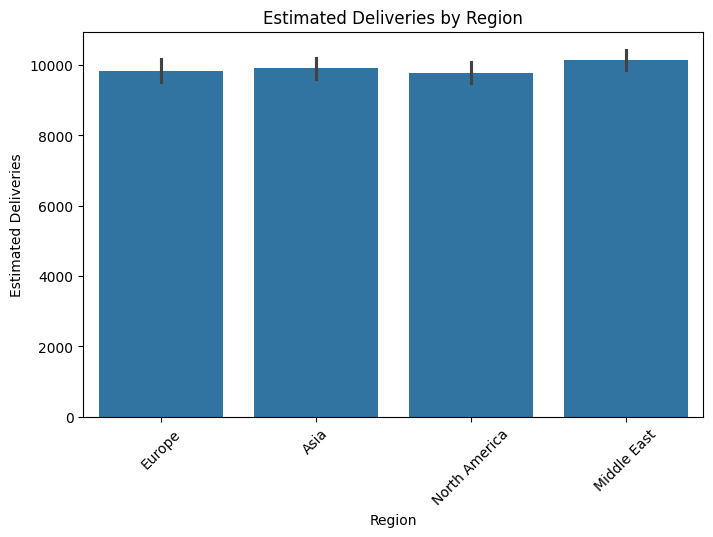

In [6]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region',
            y='Estimated_Deliveries',
            data=df)

plt.title("Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Estimated Deliveries")
plt.xticks(rotation=45)
plt.show()

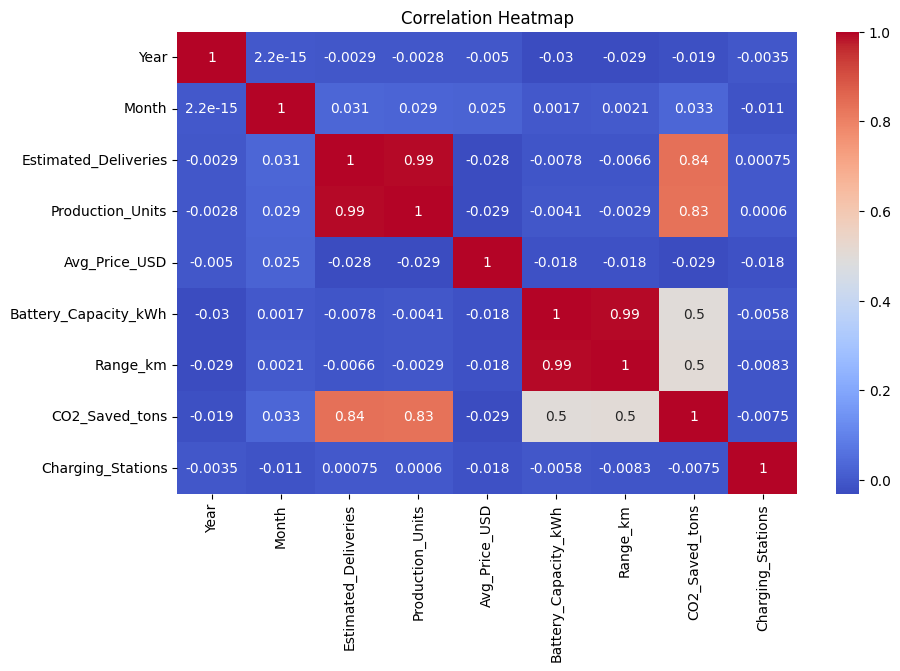

In [7]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

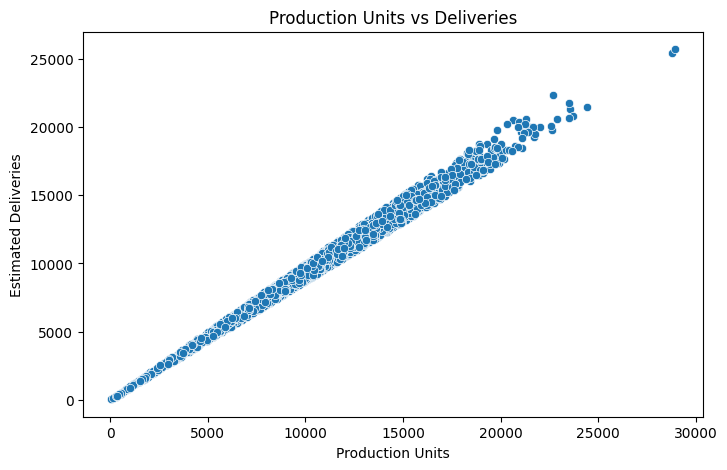

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Production_Units',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Production Units vs Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.show()

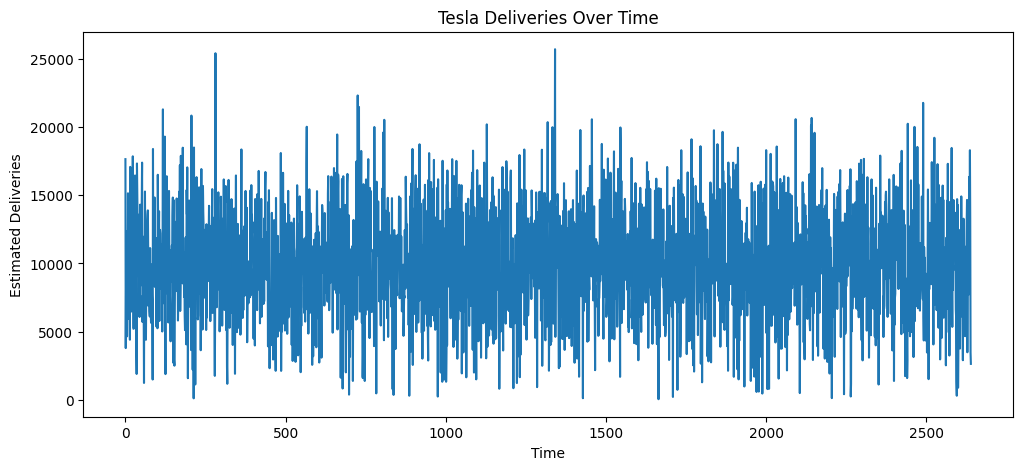

In [9]:
plt.figure(figsize=(12,5))

plt.plot(df.index,
         df['Estimated_Deliveries'])

plt.title("Tesla Deliveries Over Time")
plt.xlabel("Time")
plt.ylabel("Estimated Deliveries")
plt.show()

## Feature Engineering

Encoding categorical variables and creating lag features.

In [10]:
le = LabelEncoder()

for col in ['Region','Model','Source_Type']:
    df[col] = le.fit_transform(df[col])

In [11]:
df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)

lag_mean = df['Deliveries_Lag1'].mean()

df['Deliveries_Lag1'].fillna(lag_mean,
                             inplace=True)

In [12]:
df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(3)
    .mean()
)

roll_mean = df['Rolling_Mean_3'].mean()

df['Rolling_Mean_3'].fillna(
    roll_mean,
    inplace=True
)

In [13]:
print(df[['Deliveries_Lag1',
          'Rolling_Mean_3']].isnull().sum())

Deliveries_Lag1    0
Rolling_Mean_3     0
dtype: int64


In [14]:
assert df['Deliveries_Lag1'].isnull().sum()==0
assert df['Rolling_Mean_3'].isnull().sum()==0

## Train-Test Split

Chronological split preserving time order.

In [15]:
target = 'Estimated_Deliveries'

X = df.drop(target, axis=1)
y = df[target]

split_index = int(len(df)*0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Train Size:",len(X_train))
print("Test Size:",len(X_test))

Train Size: 2112
Test Size: 528


In [16]:
print("Train %:",
      len(X_train)/len(df)*100)

print("Test %:",
      len(X_test)/len(df)*100)

Train %: 80.0
Test %: 20.0


## Linear Regression Model

Training baseline model.

In [17]:
lr = LinearRegression()

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test,lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(y_test,lr_pred)
)

lr_r2 = r2_score(y_test,lr_pred)

print("Linear Regression Results")

print("MAE:",lr_mae)
print("RMSE:",lr_rmse)
print("R²:",lr_r2)

Linear Regression Results
MAE: 310.3345215398842
RMSE: 375.5646664534478
R²: 0.9908058721380986


## Actual vs Predicted Visualization

Evaluating prediction performance

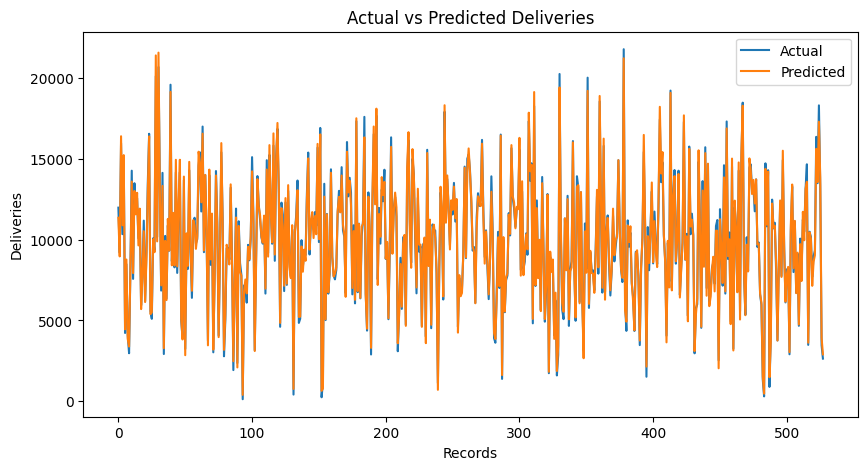

In [18]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values,
         label="Actual")

plt.plot(lr_pred,
         label="Predicted")

plt.title("Actual vs Predicted Deliveries")
plt.xlabel("Records")
plt.ylabel("Deliveries")

plt.legend()
plt.show()

## Cross Validation

Assessing model robustness using 5-fold CV.

In [19]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    lr,
    X,
    y,
    cv=kf,
    scoring='r2'
)

for i,score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}")

print("\nMean R²:",
      cv_scores.mean())

print("Std Dev:",
      cv_scores.std())

Fold 1: 0.9902
Fold 2: 0.9909
Fold 3: 0.9907
Fold 4: 0.9899
Fold 5: 0.9901

Mean R²: 0.9903758760823388
Std Dev: 0.0003651703161235434


## Random Forest Optimization

Using GridSearchCV to find best hyperparameters.

In [20]:
param_grid = {
    'n_estimators':[50,100],
    'max_depth':[5,10,None]
}

rf = RandomForestRegressor(
    random_state=42
)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train,y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'n_estimators': 50}


In [21]:
best_rf = grid.best_estimator_

rf_pred = best_rf.predict(X_test)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest Results")

print("MAE:",rf_mae)
print("RMSE:",rf_rmse)
print("R²:",rf_r2)

Random Forest Results
MAE: 303.85833333333335
RMSE: 388.5512760612014
R²: 0.99015903323468


## Feature Importance Analysis

Identifying the most influential variables.

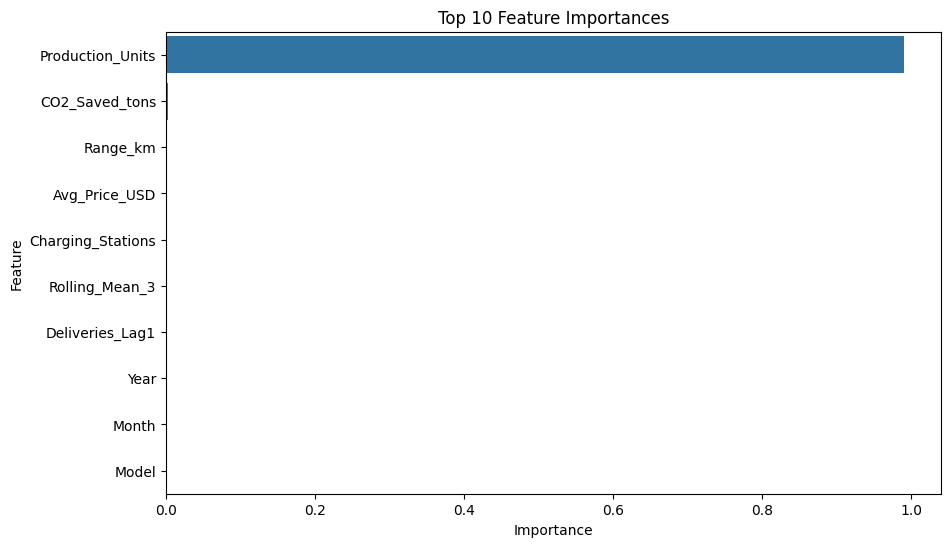

In [22]:
feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':best_rf.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top10
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Stationarity Testing and Forecasting

Using ADF test and generating forecast comparison.

In [23]:
result = adfuller(
    df['Estimated_Deliveries']
)

print("ADF Statistic:",
      result[0])

print("P-value:",
      result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

ADF Statistic: -53.82661259715622
P-value: 0.0
Series is Stationary


In [24]:
forecast_table = pd.DataFrame({
    'Actual': y_test.values[:20],
    'Predicted': rf_pred[:20]
})

forecast_table['Error_%'] = (
    abs(
        forecast_table['Actual']
        -
        forecast_table['Predicted']
    )
    /
    forecast_table['Actual']
)*100

forecast_table

,Actual,Predicted,Error_%
0,11974,11244.76,6.090195
1,9189,8947.18,2.631625
2,15956,16791.60,5.236901
3,10336,10896.56,5.423375
4,15152,15868.72,4.730201
5,4224,4014.38,4.962595
6,8475,8863.10,4.579351
7,4093,3817.50,6.731004
8,2972,3149.94,5.987214
9,8208,8202.68,0.064815


In [25]:
comparison = pd.DataFrame({

    'Model':['Linear Regression',
             'Random Forest'],

    'MAE':[lr_mae,
           rf_mae],

    'RMSE':[lr_rmse,
            rf_rmse],

    'R2':[lr_r2,
          rf_r2]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,310.334522,375.564666,0.990806
1,Random Forest,303.858333,388.551276,0.990159


## Conclusion
* Dataset successfully loaded with 12 columns.
* Five EDA visualizations generated.
* Lag and Rolling Mean features created with no  missing values.
* Chronological 80/20 split used.
* Linear Regression trained and evaluated.
* 5-Fold Cross Validation completed with Mean and  Standard Deviation reported.
* GridSearchCV identified optimal Random Forest  parameters.
* Feature Importance chart generated.
* ADF test used to determine stationarity.
* Forecast table generated for first 20 test  observations.
* Model comparison table created.
* Notebook completed without errors.


